Biblioteki zaimportowane pomyślnie.

Dane przygotowane. Liczba wierszy: 62
Liczba kolumn (zmiennych): 8


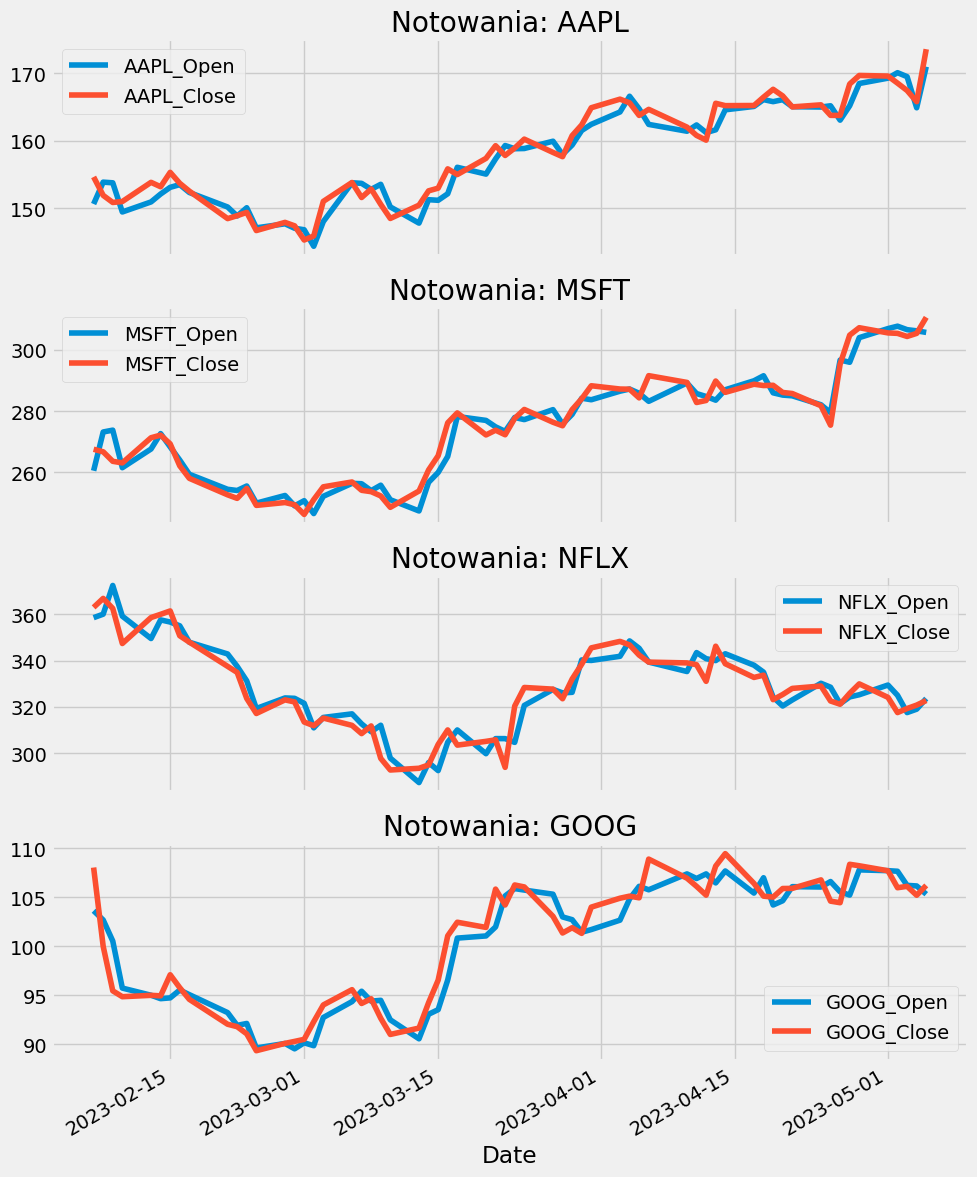


--- Sprawdzanie stacjonarności (dane surowe) ---
Liczba stacjonarnych kolumn: 0

--- Sprawdzanie stacjonarności (po różnicowaniu) ---
Sukces: Wszystkie szeregi po różnicowaniu są stacjonarne.

Dobieranie rzędu opóźnienia (maxlags=3):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       14.44      14.74*   1.865e+06       14.55
1       12.98       15.65   4.445e+05      14.01*
2       12.28       17.33   2.586e+05       14.22
3      11.15*       18.59  1.337e+05*       14.01
-------------------------------------------------

Model wytrenowany z rzędem opóźnienia: 2

Prognoza zmian cen (pierwsze 5 wierszy):
            AAPL_Open  GOOG_Open  MSFT_Open  NFLX_Open  AAPL_Close  \
Date                                                                 
2023-05-01   1.321335  -0.270540   1.804140   4.465072    1.303310   
2023-05-02   0.533679   1.160843  -2.048235   4.516155   -0.148443   
2

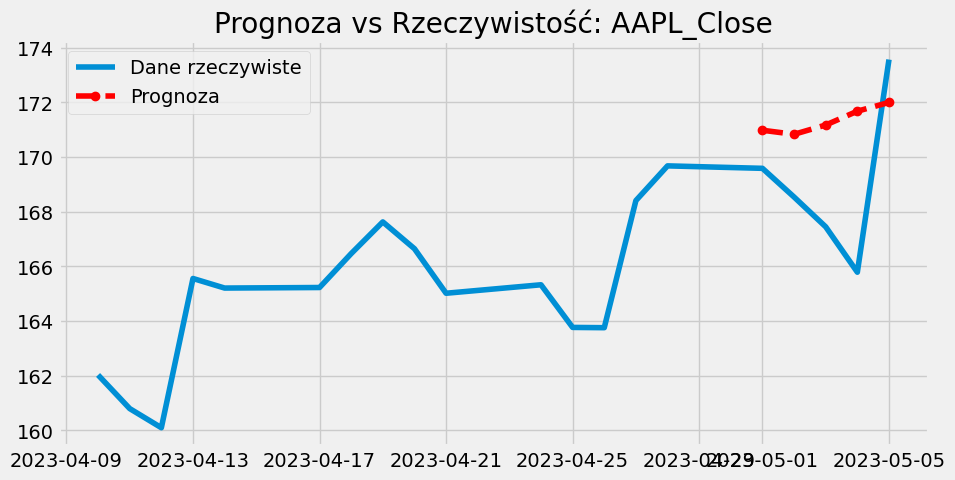

In [7]:
# ==========================================
# 1. IMPORT BIBLIOTEK
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Konfiguracja estetyki wykresów
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings("ignore") # Ignorowanie ostrzeżeń o częstotliwości dat
print("Biblioteki zaimportowane pomyślnie.")

# ==========================================
# 2. WCZYTANIE I PRZYGOTOWANIE DANYCH
# ==========================================
filepath = 'stocks.csv'
df = pd.read_csv(filepath)
df['Date'] = pd.to_datetime(df['Date'])

# Wielowymiarowe przygotowanie danych (pivot)
df_wide = df.pivot(index='Date', columns='Ticker', values=['Open', 'Close'])
df_wide.columns = [f'{col[1]}_{col[0]}' for col in df_wide.columns]
df_wide = df_wide.dropna()

# Ustawienie częstotliwości (pomaga uniknąć ValueWarning, choć przy akcjach bywają luki)
# Próbujemy ustawić 'B' (Business day), jeśli się nie uda, zostawiamy bez zmian
try:
    df_wide.index.freq = pd.infer_freq(df_wide.index)
except:
    pass

print(f"\nDane przygotowane. Liczba wierszy: {len(df_wide)}")
print(f"Liczba kolumn (zmiennych): {len(df_wide.columns)}")

# ==========================================
# 3. WIZUALIZACJA TRENDÓW
# ==========================================
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)
tickers = df['Ticker'].unique()
for i, ticker in enumerate(tickers):
    cols = [f'{ticker}_Open', f'{ticker}_Close']
    df_wide[cols].plot(ax=axes[i])
    axes[i].set_title(f'Notowania: {ticker}')
plt.tight_layout()
plt.show()

# ==========================================
# 4. TEST STACJONARNOŚCI (ADF)
# ==========================================
def run_adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    p_value = result[1]
    return p_value < 0.05

print("\n--- Sprawdzanie stacjonarności (dane surowe) ---")
stationary_cols = [col for col in df_wide.columns if run_adf_test(df_wide[col], col)]
print(f"Liczba stacjonarnych kolumn: {len(stationary_cols)}")

# ==========================================
# 5. RÓŻNICOWANIE DANYCH
# ==========================================
df_diff = df_wide.diff().dropna()

print("\n--- Sprawdzanie stacjonarności (po różnicowaniu) ---")
all_stationary = all([run_adf_test(df_diff[col], col) for col in df_diff.columns])

if all_stationary:
    print("Sukces: Wszystkie szeregi po różnicowaniu są stacjonarne.")
else:
    print("Uwaga: Niektóre szeregi nadal mogą wymagać dalszego przetwarzania.")

# ==========================================
# 6. MODELOWANIE VAR I PROGNOZA
# ==========================================
# Podział na trening i test
n_obs = 5
df_train = df_diff[:-n_obs]
df_test = df_diff[-n_obs:]

# Budowa modelu
model = VAR(df_train)

# --- POPRAWKA TUTAJ ---
# Zmieniono maxlags z 10 na 3.
# Przyczyna: Masz 8 zmiennych i tylko ~56 wierszy treningowych.
# Wzór na wymaganą liczbę danych: (Liczba zmiennych * lags) + 1 < Liczba wierszy
# (8 * 10) + 1 = 81 parametrów > 56 wierszy -> BŁĄD
# (8 * 3) + 1 = 25 parametrów < 56 wierszy -> OK

print("\nDobieranie rzędu opóźnienia (maxlags=3):")
x = model.select_order(maxlags=3)
print(x.summary())

# Trenowanie modelu (rzad 2 lub 3 jest bezpieczny)
optimal_lag = 2
model_fitted = model.fit(optimal_lag)

print(f"\nModel wytrenowany z rzędem opóźnienia: {optimal_lag}")

# Prognozowanie
lag_order = model_fitted.k_ar
forecast_input = df_train.values[-lag_order:]

# Generujemy prognozę zmian
fc = model_fitted.forecast(y=forecast_input, steps=n_obs)
df_forecast_diff = pd.DataFrame(fc, index=df_wide.index[-n_obs:], columns=df_wide.columns)

print("\nPrognoza zmian cen (pierwsze 5 wierszy):")
print(df_forecast_diff.head())

# ==========================================
# 7. ODWRÓCENIE RÓŻNICOWANIA I WYKRES
# ==========================================
df_forecast_prices = df_forecast_diff.copy()
for col in df_wide.columns:
    last_price = df_wide[col].iloc[-n_obs - 1]
    df_forecast_prices[col] = last_price + df_forecast_diff[col].cumsum()

print("\nOstateczna prognoza cen:")
print(df_forecast_prices.head())

# Wizualizacja dla jednej spółki (np. AAPL)
plt.figure(figsize=(10, 5))
col_to_plot = 'AAPL_Close'
# Pokazujemy ostatnie 20 dni rzeczywistych i 5 dni prognozy
plt.plot(df_wide.index[-20:], df_wide[col_to_plot].iloc[-20:], label='Dane rzeczywiste')
plt.plot(df_forecast_prices.index, df_forecast_prices[col_to_plot], label='Prognoza', linestyle='--', color='red', marker='o')
plt.title(f'Prognoza vs Rzeczywistość: {col_to_plot}')
plt.legend()
plt.show()

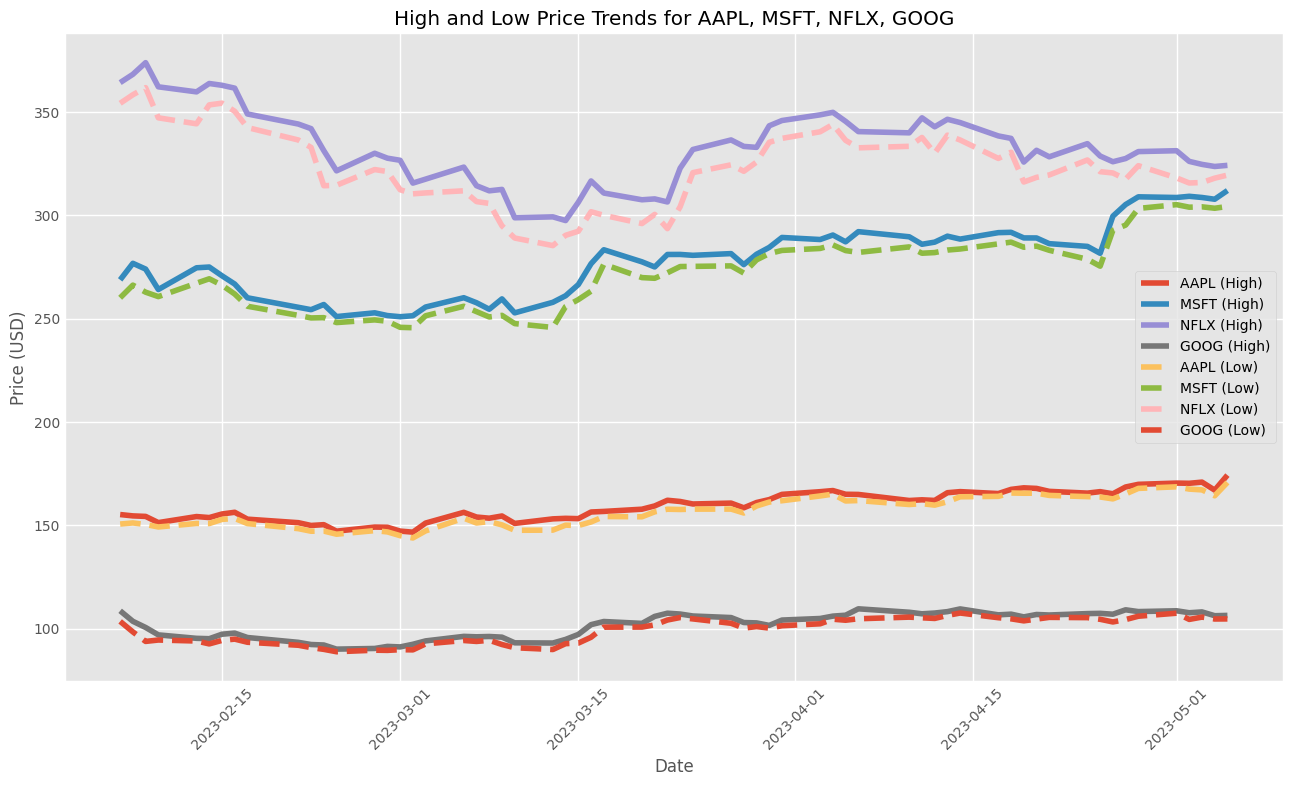

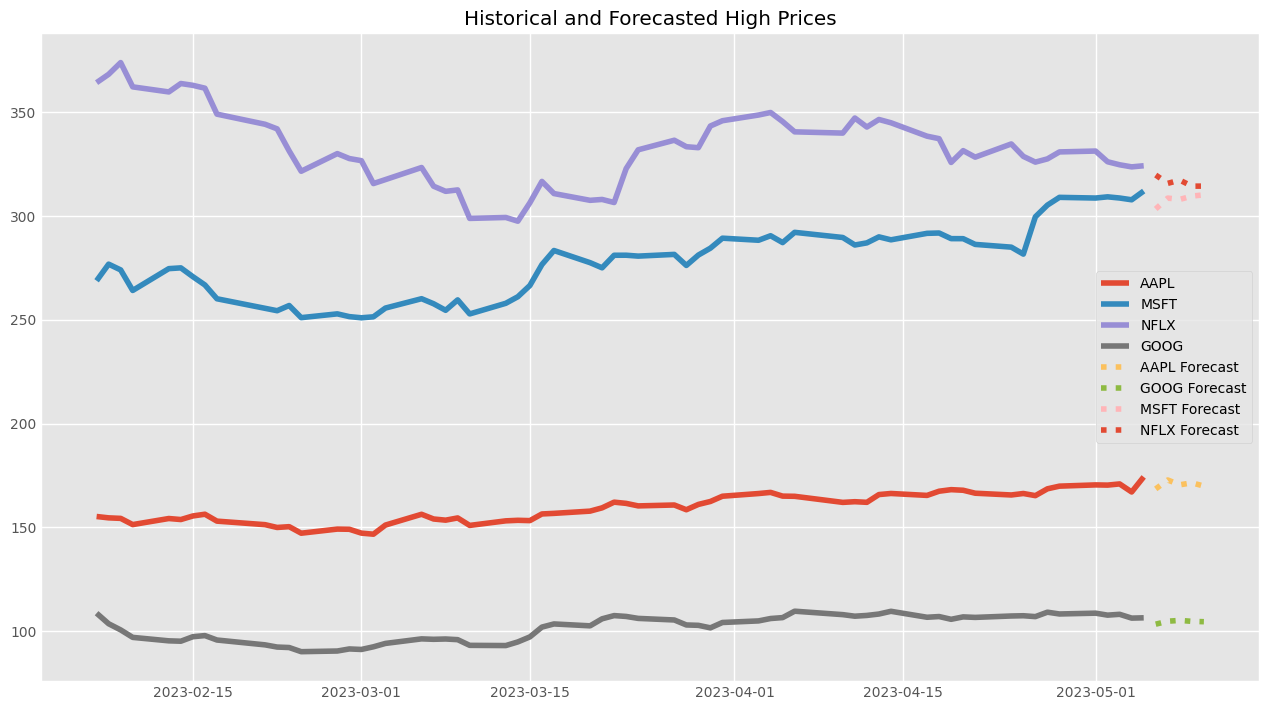

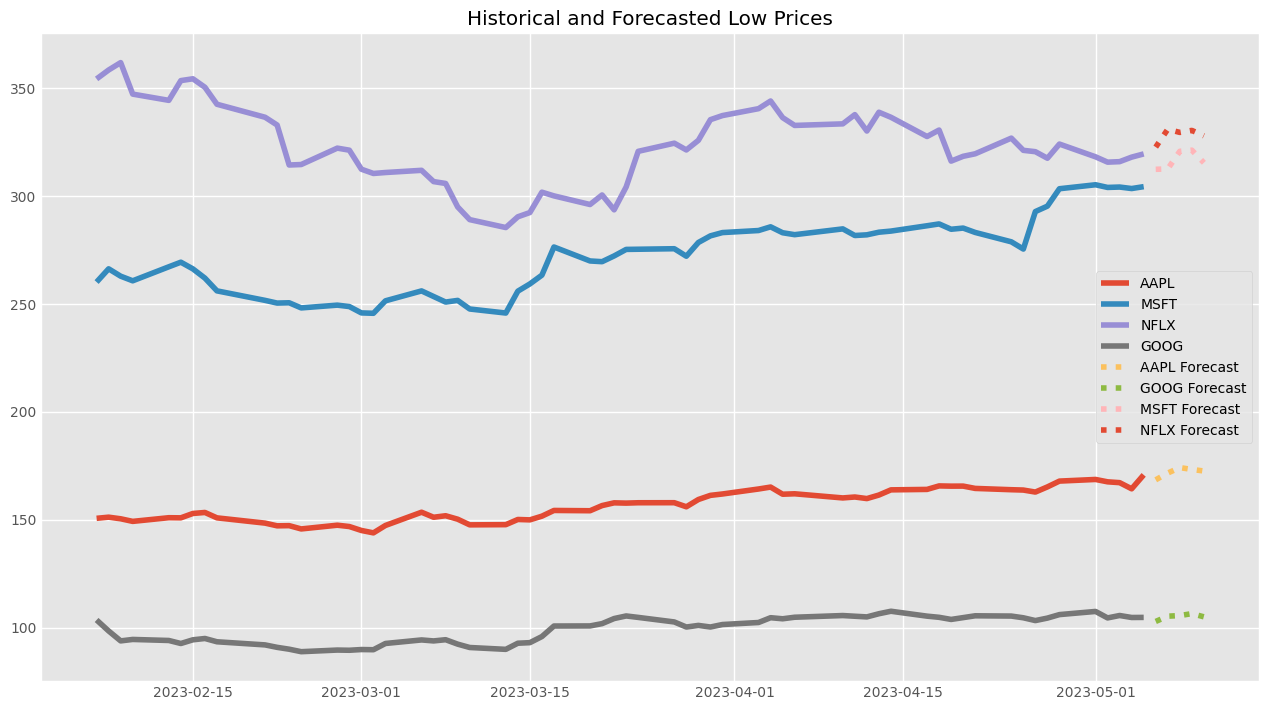

Prognoza cen High na 5 dni:
Ticker            AAPL        GOOG        MSFT        NFLX
2023-05-06  168.525756  103.379500  303.335531  319.672953
2023-05-07  172.814192  104.803418  308.576041  315.670067
2023-05-08  170.488936  105.198538  307.945047  317.241201
2023-05-09  171.458466  104.743184  309.535712  314.323642
2023-05-10  169.887831  104.569250  310.129274  314.342193

Prognoza cen Low na 5 dni:
Ticker            AAPL        GOOG        MSFT        NFLX
2023-05-06  168.470824  102.868310  312.308732  322.599265
2023-05-07  171.605922  105.305987  312.485843  330.872047
2023-05-08  174.136565  105.580455  320.640446  329.394734
2023-05-09  173.286004  106.489450  321.178899  330.323414
2023-05-10  172.549868  105.010165  315.337951  327.838077


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR

# ==========================================
# 1. WCZYTANIE I WSTĘPNA ANALIZA DANYCH
# ==========================================

# Wczytanie zestawu danych z pliku CSV
stocks_data = pd.read_csv("stocks.csv")

# Konwersja kolumny Date na typ datetime, aby umożliwić analizę szeregów czasowych
stocks_data['Date'] = pd.to_datetime(stocks_data['Date'])

# Sprawdzenie unikalnych tickerów (spółek) w danych
unique_stocks = stocks_data['Ticker'].value_counts()

# ==========================================
# 2. WIZUALIZACJA TRENDÓW (HIGH I LOW)
# ==========================================

plt.style.use('ggplot') # Changed style to 'ggplot' as 'seaborn-darkgrid' was not found
fig, ax = plt.subplots(figsize=(14, 8))

# Wykresy cen maksymalnych (High) - linie ciągłe
for ticker in unique_stocks.index:
    subset = stocks_data[stocks_data['Ticker'] == ticker]
    ax.plot(subset['Date'], subset['High'], label=f"{ticker} (High)")

# Wykresy cen minimalnych (Low) - linie przerywane dla rozróżnienia
for ticker in unique_stocks.index:
    subset = stocks_data[stocks_data['Ticker'] == ticker]
    ax.plot(subset['Date'], subset['Low'], label=f"{ticker} (Low)", linestyle='--')

ax.set_title('High and Low Price Trends for AAPL, MSFT, NFLX, GOOG')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 3. ANALIZA DLA CEN MAKSYMALNYCH (HIGH)
# ==========================================

# Różnicowanie cen High w celu uzyskania stacjonarności
stocks_data['Diff_High'] = stocks_data.groupby('Ticker')['High'].transform(lambda x: x.diff())

# Przygotowanie macierzy danych do modelu VAR (kolumny to spółki, wiersze to daty)
var_data_high = stocks_data.pivot(index='Date', columns='Ticker', values='Diff_High').dropna()

# Inicjalizacja i dopasowanie modelu VAR z opóźnieniem (lags) równym 7
model_high = VAR(var_data_high)
model_fitted_high = model_high.fit(maxlags=7)

# Definicja liczby kroków prognozy (5 dni)
forecast_steps = 5

# Generowanie prognoz dla różnic cen High
forecasted_values_high = model_fitted_high.forecast(var_data_high.values[-model_fitted_high.k_ar:], steps=forecast_steps)

# Tworzenie DataFrame z prognozami i odpowiednimi datami
forecasted_df_high = pd.DataFrame(
    forecasted_values_high,
    index=pd.date_range(start=var_data_high.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D'),
    columns=var_data_high.columns
)

# Odwrócenie różnicowania (dodawanie zmian do ostatniej znanej ceny High)
for column in forecasted_df_high.columns:
    forecasted_df_high[column] = stocks_data[stocks_data['Ticker'] == column]['High'].iloc[-1] + forecasted_df_high[column].cumsum()

# Wizualizacja prognozy High
fig, ax = plt.subplots(figsize=(14, 8))
for ticker in unique_stocks.index:
    historical_data = stocks_data[stocks_data['Ticker'] == ticker]
    ax.plot(historical_data['Date'], historical_data['High'], label=ticker)
for column in forecasted_df_high.columns:
    ax.plot(forecasted_df_high.index, forecasted_df_high[column], label=f"{column} Forecast", linestyle=':')

ax.set_title('Historical and Forecasted High Prices')
ax.legend()
plt.show()

# ==========================================
# 4. ANALIZA DLA CEN MINIMALNYCH (LOW)
# ==========================================

# Różnicowanie cen Low
stocks_data['Diff_Low'] = stocks_data.groupby('Ticker')['Low'].transform(lambda x: x.diff())

# Przygotowanie danych do modelu VAR (Low)
var_data_low = stocks_data.pivot(index='Date', columns='Ticker', values='Diff_Low').dropna()

# Dopasowanie modelu dla cen Low
model_low = VAR(var_data_low)
model_fitted_low = model_low.fit(maxlags=7)

# Generowanie prognoz dla różnic cen Low
forecasted_values_low = model_fitted_low.forecast(var_data_low.values[-model_fitted_low.k_ar:], steps=forecast_steps)

# Tworzenie DataFrame dla Low
forecasted_df_low = pd.DataFrame(
    forecasted_values_low,
    index=pd.date_range(start=var_data_low.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D'),
    columns=var_data_low.columns
)

# Odwrócenie różnicowania dla cen Low
for column in forecasted_df_low.columns:
    forecasted_df_low[column] = stocks_data[stocks_data['Ticker'] == column]['Low'].iloc[-1] + forecasted_df_low[column].cumsum()

# Wizualizacja prognozy Low
fig, ax = plt.subplots(figsize=(14, 8))
for ticker in unique_stocks.index:
    historical_data = stocks_data[stocks_data['Ticker'] == ticker]
    ax.plot(historical_data['Date'], historical_data['Low'], label=ticker)
for column in forecasted_df_low.columns:
    ax.plot(forecasted_df_low.index, forecasted_df_low[column], label=f"{column} Forecast", linestyle=':')

ax.set_title('Historical and Forecasted Low Prices')
ax.legend()
plt.show()

# Wyświetlenie tabelarycznych wyników prognozy
print("Prognoza cen High na 5 dni:")
print(forecasted_df_high)
print("\nPrognoza cen Low na 5 dni:")
print(forecasted_df_low)